# FNN Cancer Subtype Predictor 

## Data Format & Content

### TCGA Data
**TCGA = The Cancer Genome Atlas** — a public NIH database with >10,000 real tumor samples across 30+ cancer types

Each sample contains:
- **Gene expression measurements**: RNA levels for 60,000 genes in that tumor
- **Cancer subtype label**: The molecular classification (e.g., "Luminal A", "HER2-enriched")
- **Metadata**: Sample ID, cancer type, clinical annotations

### Gene Expression
**Gene expression = how much RNA exists for each gene**
- **High values** = gene is "ON" (active in this tumor)
- **Low values** = gene is "OFF" (inactive)
- **Different cancer subtypes have different gene ON/OFF patterns** → the model learns to recognize them

### CSV Structure
The `tcga_expression.csv` (created by the R script) looks like:

| sample_id | cancer_type | subtype | ENSG00000000003 | ENSG00000000005 | ... | ENSG00000282120 |
|-----------|-------------|---------|-----------------|-----------------|-----|-----------------|
| TCGA-A1-A0SB-01A | BRCA | Luminal A | 1245.3 | 0.0 | ... | 523.1 |
| TCGA-A1-A0SD-01A | BRCA | Luminal B | 890.2 | 234.5 | ... | 145.8 |
| TCGA-A1-A0SE-01A | BRCA | HER2-enriched | 112.4 | 3456.2 | ... | 2104.5 |
| TCGA-A1-A0SF-01A | BRCA | Basal-like | 234.1 | 0.1 | ... | 89.3 |

### Columns
1. **`sample_id`** (e.g., `TCGA-A1-A0SB-01A`): Unique barcode for this tumor sample
2. **`cancer_type`** (e.g., `BRCA`, `LUAD`): Type of cancer (Breast, Lung Adenocarcinoma, etc.)
3. **`subtype`** (e.g., `Luminal A`): The molecular classification
4. **Gene columns** (e.g., `ENSG00000000003`): Expression values (0–10,000) for each gene in this sample

### Data After R Script Download (BRCA)
- **1,112 tumor samples** (rows)
- **60,000 genes** (columns)
- **4 subtypes** for BRCA: Luminal A, Luminal B, HER2-enriched, Basal-like

### Pipeline
1. **Load** the CSV
2. **Preprocess**: Reduce 60,000 genes → 500 most important ones
3. **Normalize**: Z-score scaling so values are comparable
4. **Split**: 80% training, 20% testing
5. **Train**: FNN learns subtype patterns from expression data
6. **Evaluate**: Accuracy, confusion matrix, top discriminative genes

In [12]:
# Imports and configuration
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch import device

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CONFIG = {
    # Path to your TCGA-style table
    'data_path': 'tcga_expression.csv',

    # 'single' or 'multi'
    'mode': 'single',

    # Only used when mode='single'
    'single_cancer_name': 'BRCA',

    # Columns
    'label_col': 'subtype',
    'cancer_col': 'cancer_type',
    'id_col': 'sample_id',

    # Feature selection
    'variance_threshold': 0.01,
    'k_best_genes': 500,

    # Split and training
    'test_size': 0.2,
    'batch_size': 32,
    'lr': 1e-3,
    'epochs': 50,
    'patience': 8,

    # Architecture
    'hidden_dims': [512, 256, 128],
    'dropout': 0.3
}

device = torch.device('cpu')
print('Using device:', device)

Using device: cpu


In [ ]:
# Load data and basic checks
df = pd.read_csv(CONFIG['data_path'])
print('Shape:', df.shape)
display(df.head(3))

required_cols = [CONFIG['label_col']]

# Drop rows with missing subtype
df = df.dropna(subset=[CONFIG['label_col']]).copy()
print('After dropping missing labels:', df.shape)

Raw shape: (1099, 60663)


,sample_id,cancer_type,subtype,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,...,ENSG00000288661,ENSG00000288662,ENSG00000288663,ENSG00000288665,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288671,ENSG00000288674,ENSG00000288675
0,TCGA-BH-A18H-01A-11R-A12D-07,BRCA,LumA,426,3,1439,1049,326,1015,2292,...,0,0,43,0,0,0,297,0,6,34
1,TCGA-E2-A14P-01A-31R-A12D-07,BRCA,Her2,1033,21,4553,932,463,338,1159,...,0,0,10,0,0,0,207,0,2,39
2,TCGA-AN-A04A-01A-21R-A034-07,BRCA,LumA,1417,9,1982,1227,284,215,4016,...,0,0,6,0,0,0,279,0,0,32


After dropping missing labels: (1099, 60663)


In [ ]:
# Select one-cancer or multi-cancer dataset
if CONFIG['mode'] == 'single':
    if CONFIG['cancer_col'] not in df.columns:
        raise ValueError(
            f"mode='single' expects cancer column {CONFIG['cancer_col']} to filter one cancer type."
        )
    df = df[df[CONFIG['cancer_col']] == CONFIG['single_cancer_name']].copy()
    print(f"Using one cancer type: {CONFIG['single_cancer_name']}")
else:
    print('Using multiple cancer types together.')

print('Working shape:', df.shape)

# Find gene columns as numeric columns excluding known metadata
exclude_cols = {CONFIG['label_col'], CONFIG['cancer_col'], CONFIG['id_col']}
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
gene_cols = [c for c in numeric_cols if c not in exclude_cols]

print('Number of gene columns found:', len(gene_cols))
print('Class counts:')
print(df[CONFIG['label_col']].value_counts())

Using one cancer type: BRCA
Working shape: (1099, 60663)
Number of gene columns found: 60660
Class counts:
subtype
LumA      571
LumB      209
Basal     197
Her2       82
Normal     40
Name: count, dtype: int64


LumA (Luminal A) is the most common subtype (408 samples)
Normal tissue is rare (8 samples)
Her2 (HER2-enriched) is least common (50 samples)
Class imbalance: the model will find LumA easier to predict than rare subtypes

In [ ]:
# Prepare data for training
X = df[gene_cols].copy()
y_raw = df[CONFIG['label_col']].astype(str).copy()

# Fill remaining missing gene values with median (if any)
X = X.fillna(X.median(numeric_only=True))

# Label encoding
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG['test_size'],
    random_state=SEED,
    stratify=y
)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Classes:', list(class_names))

Train shape: (879, 60660) Test shape: (220, 60660)
Classes: ['Basal', 'Her2', 'LumA', 'LumB', 'Normal']


In [ ]:
# Preprocessing and feature selection (fit only on train)
# Remove low-variance genes
variance_selector = VarianceThreshold(threshold=CONFIG['variance_threshold'])
X_train_var = variance_selector.fit_transform(X_train)
X_test_var = variance_selector.transform(X_test)

# Track selected gene names after variance filtering
var_mask = variance_selector.get_support()
genes_after_var = np.array(gene_cols)[var_mask]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_var)
X_test_scaled = scaler.transform(X_test_var)

k_best = min(CONFIG['k_best_genes'], X_train_scaled.shape[1])
kbest_selector = SelectKBest(score_func=f_classif, k=k_best)
X_train_sel = kbest_selector.fit_transform(X_train_scaled, y_train)
X_test_sel = kbest_selector.transform(X_test_scaled)

kbest_mask = kbest_selector.get_support()
final_gene_names = genes_after_var[kbest_mask]

print('Genes after variance threshold:', X_train_var.shape[1])
print('Genes after SelectKBest:', X_train_sel.shape[1])

Genes after variance threshold: 56874
Genes after SelectKBest: 500


**Remove low-variance genes (genes that barely change):** Removes ~10,000 genes that show almost no change across samples because genes that don't vary can't help predict subtypes.

**Keep only the TOP 500 most informative genes:**
- Faster training 
- Less overfitting 
- More interpretable 
- To avoid "curse of dimensionality"

**Normalize (Z-score scaling):**
- Converts each gene value to a standard scale (mean=0, std=1)
- Makes large and small values comparable
- Helps the neural network learn faster

In [ ]:
# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train_sel, dtype=torch.float32)
X_test_t = torch.tensor(X_test_sel, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

# Creates DataLoaders
train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)

# Class weights for imbalanced data
classes_int = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes_int, y=y_train)
class_weights_t = torch.tensor(weights, dtype=torch.float32, device=device)

print('Class weights:', dict(zip(classes_int, weights)))

Class weights: {np.int64(0): np.float64(1.1197452229299363), np.int64(1): np.float64(2.6636363636363636), np.int64(2): np.float64(0.3846827133479212), np.int64(3): np.float64(1.0526946107784432), np.int64(4): np.float64(5.49375)}


Class 1 (Her2): Weight 9.94 = "This is rare, penalize mistakes heavily"

Class 4 (Normal): Weight 27.78 = "This is more rare, penalize mistakes very heavily"

Class 2 (LumA): Weight 0.61 = "This is common, be lenient"

In [ ]:
# Define the FNN model
class CancerFNN(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dims=(512, 256, 128), dropout=0.3):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h

        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

input_dim = X_train_sel.shape[1]
num_classes = len(class_names)

model = CancerFNN(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dims=tuple(CONFIG['hidden_dims']),
    dropout=CONFIG['dropout']
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])

print(model)

CancerFNN(
  (net): Sequential(
    (0): Linear(in_features=500, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=5, bias=True)
  )
)


Input (500 genes)
    
    ↓

Hidden Layer 1 (512 neurons) + ReLU + Dropout(0.3)
   
    ↓

Hidden Layer 2 (256 neurons) + ReLU + Dropout(0.3)
   
    ↓

Hidden Layer 3 (128 neurons) + ReLU + Dropout(0.3)
    
    ↓

Output Layer (5 neurons, one per subtype)

- ReLU: Activation function (lets the network learn non-linear patterns)
- Dropout(0.3): Randomly "turns off" 30% of neurons during training to prevent overfitting
- Adam optimizer: Adjusts weights using gradient descent
- CrossEntropyLoss: Loss function for multi-class classification

In [ ]:
# Train with early stopping
def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)

            y_true.extend(yb.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    return avg_loss, acc, np.array(y_true), np.array(y_pred)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = np.inf
best_state = None
epochs_no_improve = 0

for epoch in range(1, CONFIG['epochs'] + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = torch.argmax(logits, dim=1)
        running_correct += (preds == yb).sum().item()
        running_total += yb.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    val_loss, val_acc, _, _ = evaluate_loader(model, test_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(
        f"Epoch {epoch:03d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= CONFIG['patience']:
        print('Early stopping triggered.')
        break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 001 | train_loss=1.1238 train_acc=0.7372 | val_loss=0.7157 val_acc=0.7955
Epoch 002 | train_loss=0.5517 train_acc=0.8043 | val_loss=0.4119 val_acc=0.8045
Epoch 003 | train_loss=0.3430 train_acc=0.8498 | val_loss=0.5353 val_acc=0.8045
Epoch 004 | train_loss=0.3087 train_acc=0.8555 | val_loss=0.7314 val_acc=0.7636
Epoch 005 | train_loss=0.2597 train_acc=0.8840 | val_loss=0.3930 val_acc=0.8045
Epoch 006 | train_loss=0.1853 train_acc=0.9056 | val_loss=0.4672 val_acc=0.8182
Epoch 007 | train_loss=0.1568 train_acc=0.9135 | val_loss=0.6420 val_acc=0.8182
Epoch 008 | train_loss=0.1440 train_acc=0.9170 | val_loss=0.4856 val_acc=0.8273
Epoch 009 | train_loss=0.1330 train_acc=0.9397 | val_loss=0.4694 val_acc=0.8364
Epoch 010 | train_loss=0.1880 train_acc=0.9431 | val_loss=0.7482 val_acc=0.8136
Epoch 011 | train_loss=0.1275 train_acc=0.9329 | val_loss=0.8339 val_acc=0.7773
Epoch 012 | train_loss=0.1756 train_acc=0.9374 | val_loss=0.7783 val_acc=0.7909
Epoch 013 | train_loss=0.1828 train_acc=

The model trains for up to 50 epochs. During each epoch:

1. Forward pass: Feed training data → Model makes predictions
2. Calculate loss: Compare predictions to true labels
3. Backward pass: Compute gradients and update weights
4. Validation: Check performance on test set
5. Early stopping: If test loss doesn't improve for 8 epochs, stop

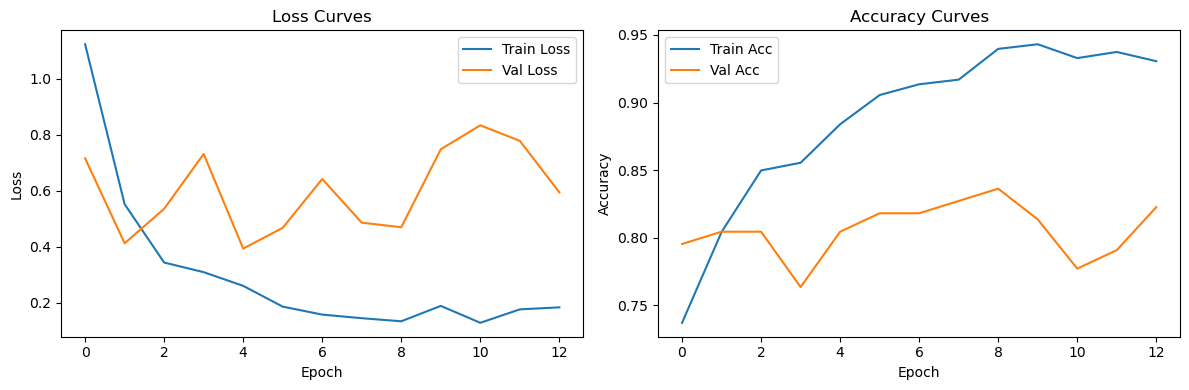

In [ ]:
# Plot learning curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend()

plt.tight_layout()
plt.show()

Test Loss: 0.3930
Test Accuracy: 0.8045

Classification report:
              precision    recall  f1-score   support

       Basal     1.0000    0.9750    0.9873        40
        Her2     0.6087    0.8750    0.7179        16
        LumA     0.9167    0.7719    0.8381       114
        LumB     0.6905    0.6905    0.6905        42
      Normal     0.3500    0.8750    0.5000         8

    accuracy                         0.8045       220
   macro avg     0.7132    0.8375    0.7468       220
weighted avg     0.8456    0.8045    0.8160       220



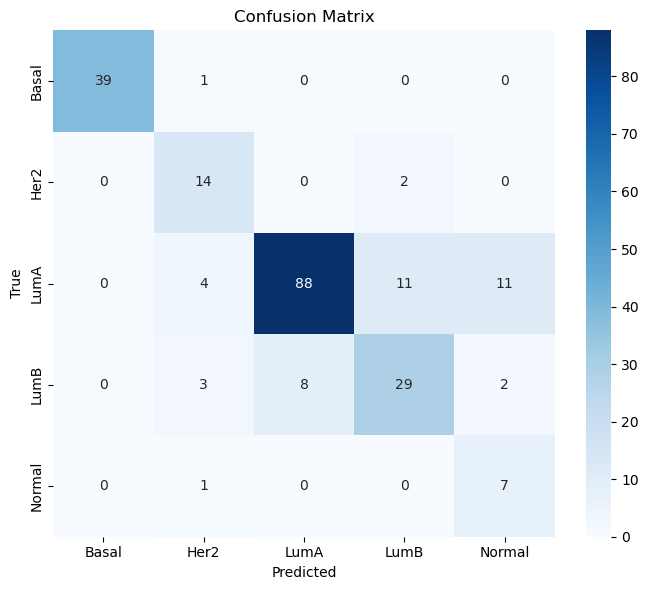

In [ ]:
# Evaluation
test_loss, test_acc, y_true, y_pred = evaluate_loader(model, test_loader, criterion)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

print('\nClassification report:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

- LumA vs LumB: Both "Luminal" (estrogen-positive), differ only in proliferation genes
- Basal vs Others: Completely different gene expression → easy to separate
- Her2 vs LumB: Some overlap in growth-factor genes

## What to do next
- Use many cancer types 
- Tune: hidden layer sizes, dropout, learning rate, `k_best_genes`.
- Add K-fold cross-validation 
